# JobFit — Phase 4 : Clustering des offres

Regrouper les offres par profils similaires avec KMeans. Visualisation 2D + analyse des clusters.

In [14]:
import sys, os

base = os.path.expanduser('~/WORKSPACE /PROJETS FIN FORMATION JEDHA/NOUVEAU TAFF/jobfit_phase2')
sys.path.insert(0, os.path.join(base, 'src/ml'))
sys.path.insert(0, os.path.join(base, 'src/nlp'))
sys.path.insert(0, os.path.join(base, 'src/api'))
os.environ['MLFLOW_TRACKING_URI'] = os.path.join(base, 'mlruns')
os.environ['DATA_PROCESSED']      = os.path.join(base, 'data/processed')

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from cv_parser  import parse_cv
from embeddings import EmbeddingEngine
from clustering import (
    reduce_dimensions, find_optimal_k, kmeans_clustering,
    analyze_clusters, plot_elbow, plot_clusters_2d, plot_cluster_sizes
)

DATA_DIR   = os.path.join(base, 'data/processed')
CV_PATH    = os.path.join(base, 'data/cv/sample_cv.pdf')
MODELS_DIR = os.path.join(base, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup OK.')

Setup OK.


## 1. Chargement des données

In [15]:
# Offres
conn      = sqlite3.connect(f'{DATA_DIR}/jobfit.db')
df_offres = pd.read_sql('SELECT * FROM offres', conn)
conn.close()
print(f'Offres : {len(df_offres)}')

# Embeddings pré-calculés
offres_embeddings = np.load(f'{DATA_DIR}/offres_embeddings.npy')
cv_embedding      = np.load(f'{DATA_DIR}/cv_embedding.npy')
print(f'Embeddings offres : {offres_embeddings.shape}')
print(f'Embedding CV      : {cv_embedding.shape}')

Offres : 6014
Embeddings offres : (6014, 384)
Embedding CV      : (384,)


## 2. Réduction de dimension (PCA 2D)

In [16]:
print('Réduction PCA...')
embeddings_2d = reduce_dimensions(offres_embeddings, n_components=2, method='pca')

# Réduire le CV dans le même espace
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
pca.fit(offres_embeddings)
cv_2d = pca.transform(cv_embedding.reshape(1, -1))

print(f'Embeddings 2D shape : {embeddings_2d.shape}')
print(f'Variance expliquée  : {pca.explained_variance_ratio_.sum():.2%}')

Réduction PCA...
Embeddings 2D shape : (6014, 2)
Variance expliquée  : 11.95%


## 3. Trouver le K optimal

Recherche du K optimal (K=2 à 11)...

  K= 2 | Inertia: 3,278 | Silhouette: 0.0678
  K= 3 | Inertia: 3,159 | Silhouette: 0.0518
  K= 4 | Inertia: 3,087 | Silhouette: 0.0475
  K= 5 | Inertia: 3,022 | Silhouette: 0.0560
  K= 6 | Inertia: 2,958 | Silhouette: 0.0575
  K= 7 | Inertia: 2,905 | Silhouette: 0.0487
  K= 8 | Inertia: 2,862 | Silhouette: 0.0485
  K= 9 | Inertia: 2,827 | Silhouette: 0.0526
  K=10 | Inertia: 2,796 | Silhouette: 0.0472
  K=11 | Inertia: 2,765 | Silhouette: 0.0519

Meilleur K (silhouette) : 2


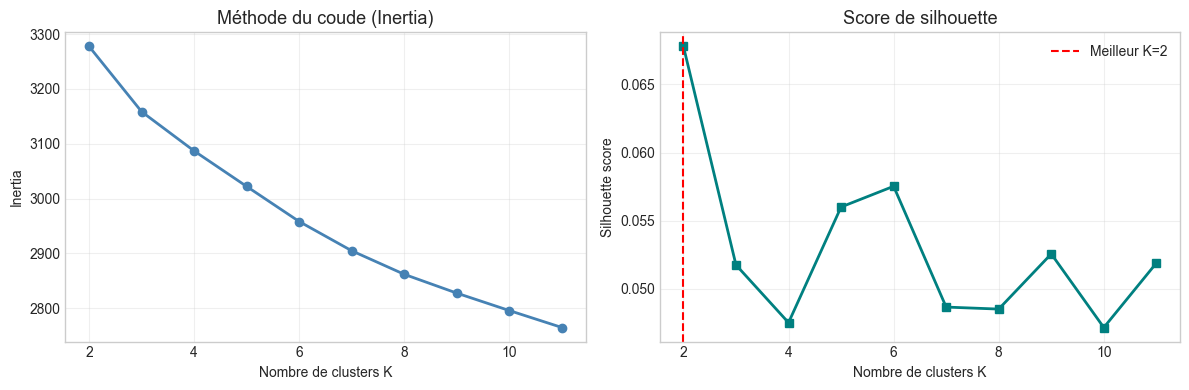

In [17]:
print('Recherche du K optimal (K=2 à 11)...\n')
results = find_optimal_k(offres_embeddings, k_range=range(2, 12))

print(f'\nMeilleur K (silhouette) : {results["best_k"]}')

plot_elbow(
    results['k_range'],
    results['inertias'],
    results['silhouettes'],
    save_path=f'{DATA_DIR}/clustering_elbow.png'
)

## 4. KMeans avec le meilleur K

In [18]:
import mlflow
mlflow.set_tracking_uri(os.path.join(base, 'mlruns'))

best_k = results['best_k']
print(f'Clustering avec K={best_k}...')

labels, km_model = kmeans_clustering(
    offres_embeddings,
    n_clusters=best_k,
    experiment_name='jobfit_clustering'
)

df_offres['cluster'] = labels
print(f'\nRépartition des clusters :')
print(df_offres['cluster'].value_counts().sort_index())

Clustering avec K=2...
KMeans K=2 | Silhouette: 0.0561 | Davies-Bouldin: 4.2777

Répartition des clusters :
cluster
0    1892
1    4122
Name: count, dtype: int64


## 5. Visualisation 2D

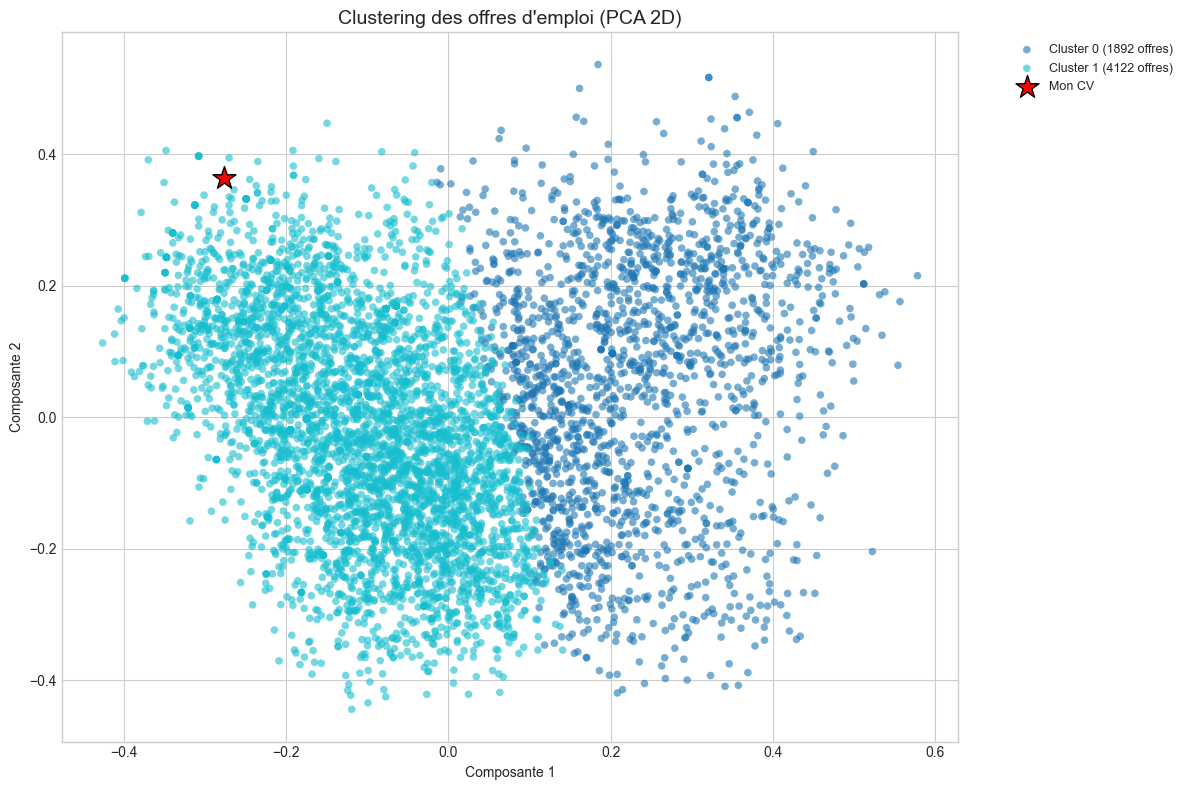

In [19]:
plot_clusters_2d(
    embeddings_2d,
    labels,
    df_offres,
    cv_embedding_2d=cv_2d[0],  # ← ajoute [0] pour prendre la première ligne
    save_path=f'{DATA_DIR}/clusters_2d.png'
)

## 6. Analyse des clusters

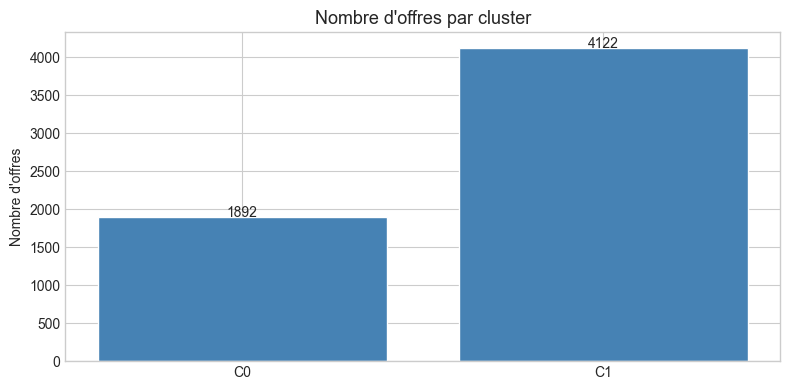


--- PROFIL DE CHAQUE CLUSTER ---


,cluster,nb_offres,top_titres,top_competences,contrat_dominant
0,0,1892,Avocat / Avocate (H/F) | Cuisinier / Cuisinière (H/F),"Enseigner, transmettre des connaissances, développer des...",CDI
1,1,4122,Graphiste concepteur / conceptrice (H/F) | Analyste fina...,"Analyser, exploiter, structurer des données, Recueillir ...",CDI


In [20]:
cluster_stats = analyze_clusters(df_offres, labels, best_k)

plot_cluster_sizes(cluster_stats, save_path=f'{DATA_DIR}/cluster_sizes.png')

print('\n--- PROFIL DE CHAQUE CLUSTER ---')
pd.set_option('display.max_colwidth', 60)
cluster_stats[['cluster', 'nb_offres', 'top_titres', 'top_competences', 'contrat_dominant']]

In [21]:
# Identifier dans quel cluster tombe le CV
cv_cluster = km_model.predict(cv_embedding.reshape(1, -1))[0]
print(f'Le CV appartient au cluster : {cv_cluster}')
print(f'\nProfil de ce cluster :')
print(cluster_stats[cluster_stats['cluster'] == cv_cluster].to_string(index=False))

print(f'\nOffres du même cluster (top 10) :')
df_same_cluster = df_offres[df_offres['cluster'] == cv_cluster]
df_same_cluster[['intitule', 'entreprise', 'lieu', 'type_contrat']].head(10)

Le CV appartient au cluster : 1

Profil de ce cluster :
 cluster  nb_offres                                                                       top_titres                                                                        top_competences contrat_dominant lieu_dominant
       1       4122 Graphiste concepteur / conceptrice (H/F) | Analyste financier / financière (H/F) Analyser, exploiter, structurer des données, Recueillir et analyser les besoins client              CDI    75 - Paris

Offres du même cluster (top 10) :


,intitule,entreprise,lieu,type_contrat
0,DATA SCIENTIST (H/F),SEGMENT ELITE,75 - PARIS,CDI
1,Data Engineer / Data Scientist (H/F),ADHOC CONSULT,75 - PARIS 14,CDI
2,Data scientist (H/F),IRLY,Ile-de-France,CDI
3,Data scientist (H/F),MCCANN ERICKSON PARIS,92 - NEUILLY SUR SEINE,CDI
4,R&D Data Scientist (H/F),WIZBII,44 - Nantes,CDI
5,Data Scientist - Neurosciences (H/F),,91 - LONGJUMEAU,CDI
6,Data scientist (H/F),LITTLEBIGCODE,75 - PARIS 17,CDI
7,Data Scientist Senior F/H,SOCOTEC TECHNICAL CONSULTING,91 - Palaiseau,CDI
8,Forward-Deployed Data Scientist II (H/F),,75 - PARIS 09,CDI
9,SENIOR DATA SCIENTIST - IA et robotique embarquées (H/F),REEV SAS,31 - Toulouse,CDI


In [22]:
# Sauvegarder
import joblib
df_offres.to_csv(f'{DATA_DIR}/offres_clustered.csv', index=False)
joblib.dump(km_model, f'{MODELS_DIR}/kmeans_model.pkl')
np.save(f'{DATA_DIR}/embeddings_2d.npy', embeddings_2d)

print('Fichiers sauvegardés :')
print(f'  {DATA_DIR}/offres_clustered.csv')
print(f'  {MODELS_DIR}/kmeans_model.pkl')
print(f'  {DATA_DIR}/embeddings_2d.npy')

Fichiers sauvegardés :
  /Users/martialbayom/WORKSPACE /PROJETS FIN FORMATION JEDHA/NOUVEAU TAFF/jobfit_phase2/data/processed/offres_clustered.csv
  /Users/martialbayom/WORKSPACE /PROJETS FIN FORMATION JEDHA/NOUVEAU TAFF/jobfit_phase2/models/kmeans_model.pkl
  /Users/martialbayom/WORKSPACE /PROJETS FIN FORMATION JEDHA/NOUVEAU TAFF/jobfit_phase2/data/processed/embeddings_2d.npy
